In [5]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


# **Environment Setup**

In [6]:
if torch.cuda.is_available():
    gpu_properties = torch.cuda.get_device_properties(0)

    print("GPU:", gpu_properties.name)
    print("Total GPU memory:",
          round(gpu_properties.total_memory / 1024**3, 2), "GB")

GPU: Tesla T4
Total GPU memory: 14.56 GB


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("NumPy:", np.__version__)
print("PIL: OK")
print("Matplotlib: OK")

NumPy: 2.0.2
PIL: OK
Matplotlib: OK


# Project Directories

In [8]:
from pathlib import Path

BASE_DIR = Path("/kaggle/working/underwater_research")

directories = [
    "data",
    "checkpoints",
    "outputs",
    "results",
    "logs"
]

for directory in directories:
    (BASE_DIR / directory).mkdir(parents=True, exist_ok=True)

print("Project directory:", BASE_DIR)

Project directory: /kaggle/working/underwater_research


In [9]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [10]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)

Using device: cuda


# GPU Test

In [11]:
if torch.cuda.is_available():

    x = torch.randn(2048, 2048, device=DEVICE)
    y = torch.randn(2048, 2048, device=DEVICE)

    z = x @ y

    print("GPU computation successful!")
    print("Result shape:", z.shape)

    del x, y, z
    torch.cuda.empty_cache()

else:
    print("GPU is not available.")

GPU computation successful!
Result shape: torch.Size([2048, 2048])


In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("larjeck/uieb-dataset-raw")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/larjeck/uieb-dataset-raw


In [13]:
from pathlib import Path

# Kaggle dataset path
dataset_path = Path("/kaggle/input/datasets/larjeck/uieb-dataset-raw")

print("Dataset exists:", dataset_path.exists())
print("Dataset path:", dataset_path)

Dataset exists: True
Dataset path: /kaggle/input/datasets/larjeck/uieb-dataset-raw


In [14]:
from pathlib import Path

base = Path("/kaggle/input")

for path in base.rglob("*"):
    if path.is_dir() and path.name in ["raw-890", "reference-890", "challenging-60"]:
        print(path)

/kaggle/input/datasets/mdabdullah909/challenging-60
/kaggle/input/datasets/larjeck/uieb-dataset-reference/reference-890
/kaggle/input/datasets/larjeck/uieb-dataset-raw/raw-890
/kaggle/input/datasets/mdabdullah909/challenging-60/challenging-60


In [15]:
from pathlib import Path

raw_dir = Path("/kaggle/input/datasets/larjeck/uieb-dataset-raw/raw-890")
reference_dir = Path("/kaggle/input/datasets/larjeck/uieb-dataset-reference/reference-890")
challenging_dir = Path("/kaggle/input/datasets/mdabdullah909/challenging-60/challenging-60")

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

raw_images = [p for p in raw_dir.iterdir() if p.suffix.lower() in extensions]
reference_images = [p for p in reference_dir.iterdir() if p.suffix.lower() in extensions]
challenging_images = [p for p in challenging_dir.iterdir() if p.suffix.lower() in extensions]

print("Raw images:        ", len(raw_images))
print("Reference images:  ", len(reference_images))
print("Challenging images:", len(challenging_images))

Raw images:         890
Reference images:   890
Challenging images: 60


# Reference Pairs


In [16]:
from pathlib import Path

raw_dir = Path("/kaggle/input/datasets/larjeck/uieb-dataset-raw/raw-890")
reference_dir = Path("/kaggle/input/datasets/larjeck/uieb-dataset-reference/reference-890")
challenging_dir = Path("/kaggle/input/datasets/mdabdullah909/challenging-60/challenging-60")

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

raw_files = sorted([
    p for p in raw_dir.iterdir()
    if p.suffix.lower() in extensions
])

reference_files = sorted([
    p for p in reference_dir.iterdir()
    if p.suffix.lower() in extensions
])

challenging_files = sorted([
    p for p in challenging_dir.iterdir()
    if p.suffix.lower() in extensions
])

raw_names = {p.stem for p in raw_files}
reference_names = {p.stem for p in reference_files}

print("Raw:", len(raw_files))
print("Reference:", len(reference_files))
print("Challenging:", len(challenging_files))

print("\nRaw without reference:", len(raw_names - reference_names))
print("Reference without raw:", len(reference_names - raw_names))

if raw_names == reference_names:
    print("\n✅ Every raw image has a matching reference image.")
else:
    print("\n⚠️ Some pairs are missing.")
    
    print("\nRaw without reference:")
    print(sorted(raw_names - reference_names)[:20])

    print("\nReference without raw:")
    print(sorted(reference_names - raw_names)[:20])

Raw: 890
Reference: 890
Challenging: 60

Raw without reference: 0
Reference without raw: 0

✅ Every raw image has a matching reference image.


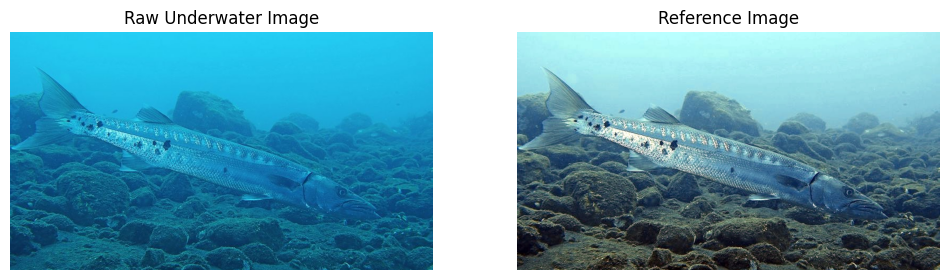

Raw: 100_img_.png
Reference: 100_img_.png


In [17]:
import matplotlib.pyplot as plt
from PIL import Image

sample_raw = raw_files[0]

# Find corresponding reference image
sample_reference = reference_dir / sample_raw.name

raw_img = Image.open(sample_raw)
ref_img = Image.open(sample_reference)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(raw_img)
plt.title("Raw Underwater Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ref_img)
plt.title("Reference Image")
plt.axis("off")

plt.show()

print("Raw:", sample_raw.name)
print("Reference:", sample_reference.name)

In [18]:
import random

SEED = 42

paired_files = sorted(raw_files)

random.seed(SEED)
random.shuffle(paired_files)

train_files = paired_files[:800]
test_files = paired_files[800:]

print("Training images:", len(train_files))
print("Paired test images:", len(test_files))

Training images: 800
Paired test images: 90


In [19]:
import json

split = {
    "seed": SEED,
    "train": [p.name for p in train_files],
    "test": [p.name for p in test_files],
    "challenging": [p.name for p in challenging_files]
}

with open("/kaggle/working/uieb_split.json", "w") as f:
    json.dump(split, f, indent=4)

print("✅ Split saved.")
print("Location: /kaggle/working/uieb_split.json")

✅ Split saved.
Location: /kaggle/working/uieb_split.json


# Setting Spatial Transformation

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from PIL import Image
import random

class UIEBDataset(Dataset):
    def __init__(
        self,
        filenames,
        raw_dir,
        reference_dir,
        image_size=256,
        training=True
    ):
        self.filenames = filenames
        self.raw_dir = raw_dir
        self.reference_dir = reference_dir
        self.image_size = image_size
        self.training = training

        # Reference image lookup
        self.reference_map = {
            p.stem: p
            for p in reference_dir.iterdir()
            if p.suffix.lower() in extensions
        }

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):

        filename = self.filenames[idx]

        # -----------------------------
        # Load images
        # -----------------------------
        raw_path = self.raw_dir / filename

        reference_path = self.reference_map[Path(filename).stem]

        raw_img = Image.open(raw_path).convert("RGB")
        reference_img = Image.open(reference_path).convert("RGB")

        # -----------------------------
        # Training transformations
        # -----------------------------
        if self.training:

            # Make sure image is at least 256x256
            w, h = raw_img.size

            if w < self.image_size or h < self.image_size:

                new_w = max(w, self.image_size)
                new_h = max(h, self.image_size)

                raw_img = TF.resize(raw_img, [new_h, new_w])
                reference_img = TF.resize(
                    reference_img, [new_h, new_w]
                )

            # Random crop
            i, j, h, w = torch.randint(
                0,
                raw_img.height - self.image_size + 1,
                (1,)
            ).item(), torch.randint(
                0,
                raw_img.width - self.image_size + 1,
                (1,)
            ).item(), self.image_size, self.image_size

            # IMPORTANT:
            # Same crop for input and reference
            raw_img = TF.crop(raw_img, i, j, h, w)
            reference_img = TF.crop(
                reference_img, i, j, h, w
            )

            # Random horizontal flip
            if random.random() < 0.5:
                raw_img = TF.hflip(raw_img)
                reference_img = TF.hflip(reference_img)

            # Random rotation
            rotation = random.choice([0, 90, 180, 270])

            if rotation != 0:
                raw_img = TF.rotate(raw_img, rotation)
                reference_img = TF.rotate(
                    reference_img, rotation
                )

        # -----------------------------
        # Testing transformation
        # -----------------------------
        else:

            raw_img = TF.resize(
                raw_img,
                [self.image_size, self.image_size]
            )

            reference_img = TF.resize(
                reference_img,
                [self.image_size, self.image_size]
            )

        # -----------------------------
        # Convert to tensors
        # -----------------------------
        raw_tensor = TF.to_tensor(raw_img)
        reference_tensor = TF.to_tensor(reference_img)

        # IMPORTANT:
        # Return filename as STRING, not Path
        return {
            "input": raw_tensor,
            "target": reference_tensor,
            "filename": filename.name
        }

# Splitting Dataset after Image Processing

In [21]:
train_dataset = UIEBDataset(
    filenames=train_files,
    raw_dir=raw_dir,
    reference_dir=reference_dir,
    image_size=256,
    training=True
)

test_dataset = UIEBDataset(
    filenames=test_files,
    raw_dir=raw_dir,
    reference_dir=reference_dir,
    image_size=256,
    training=False
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 800
Test samples: 90


# Dataloaders

In [22]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training batches: 100
Test batches: 12


# First Branch checck


In [23]:
batch = next(iter(train_loader))

inputs = batch["input"]
targets = batch["target"]
filenames = batch["filename"]

print("Input shape: ", inputs.shape)
print("Target shape:", targets.shape)

print("Input range:",
      inputs.min().item(),
      "to",
      inputs.max().item())

print("Target range:",
      targets.min().item(),
      "to",
      targets.max().item())

print("First filenames:", filenames[:3])

Input shape:  torch.Size([8, 3, 256, 256])
Target shape: torch.Size([8, 3, 256, 256])
Input range: 0.0 to 1.0
Target range: 0.0 to 1.0
First filenames: ['326_img_.png', '268_img_.png', '432_img_.png']


# GPU test


In [24]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

inputs_gpu = inputs.to(device, non_blocking=True)
targets_gpu = targets.to(device, non_blocking=True)

print("Device:", device)
print("Input GPU shape:", inputs_gpu.shape)
print("Target GPU shape:", targets_gpu.shape)
print("Input device:", inputs_gpu.device)

Device: cuda
Input GPU shape: torch.Size([8, 3, 256, 256])
Target GPU shape: torch.Size([8, 3, 256, 256])
Input device: cuda:0


# Baseline U-Net

In [25]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Downsampling
        self.pool = nn.MaxPool2d(kernel_size=2)

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024, 512, kernel_size=2, stride=2
        )
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512, 256, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(128, 64)

        # Output
        self.output = nn.Conv2d(
            64, 3, kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # Keep output in [0, 1]
        out = torch.sigmoid(self.output(d1))

        return out

In [26]:
model = UNetBaseline().to(device)

print(model)

UNetBaseline(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc4): DoubleConv(
    (block): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): 

In [27]:
num_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Total parameters: {num_params:,}")
print(f"Total parameters: {num_params / 1e6:.2f} M")

Total parameters: 31,031,875
Total parameters: 31.03 M


# Forward Pass test

In [28]:
model.eval()

with torch.no_grad():
    output = model(inputs_gpu)

print("Input shape: ", inputs_gpu.shape)
print("Output shape:", output.shape)
print(
    "Output range:",
    output.min().item(),
    "to",
    output.max().item()
)

Input shape:  torch.Size([8, 3, 256, 256])
Output shape: torch.Size([8, 3, 256, 256])
Output range: 0.4977862238883972 to 0.5241334438323975


In [29]:
!pip install -q torchmetrics


In [30]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

print("PSNR and SSIM ready.")

PSNR and SSIM ready.


In [31]:
import torch

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer created successfully!")
print(optimizer)

Optimizer created successfully!
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [32]:
print(model)
print(device)

UNetBaseline(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc4): DoubleConv(
    (block): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): 

In [33]:
import torch.nn as nn

criterion = nn.L1Loss()

print("Criterion created successfully!")
print(criterion)

Criterion created successfully!
L1Loss()


In [34]:
print("Model:", type(model).__name__)
print("Criterion:", criterion)
print("Optimizer:", optimizer)
print("Device:", device)

Model: UNetBaseline
Criterion: L1Loss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Device: cuda


In [35]:
import torch
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
model = UNetBaseline().to(device)

# L1 loss
criterion = nn.L1Loss()

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Scheduler
NUM_EPOCHS = 20

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

print("All baseline training components are ready!")
print("Device:", device)
print("Criterion:", criterion)
print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")

All baseline training components are ready!
Device: cuda
Criterion: L1Loss()
Optimizer: AdamW
Scheduler: CosineAnnealingLR


In [36]:
import time
import os

NUM_EPOCHS = 20

best_train_loss = float("inf")

history = {
    "train_loss": [],
    "lr": []
}

checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(NUM_EPOCHS):

    model.train()

    epoch_loss = 0.0
    start_time = time.time()

    for batch in train_loader:

        inputs = batch["input"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        # Clear old gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        outputs = model(inputs)

        # L1 loss
        loss = criterion(outputs, targets)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_loss += loss.item()

    # Average loss
    avg_loss = epoch_loss / len(train_loader)

    # Current learning rate
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(avg_loss)
    history["lr"].append(current_lr)

    # Learning-rate update
    scheduler.step()

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"Loss: {avg_loss:.6f} "
        f"LR: {current_lr:.7f} "
        f"Time: {elapsed:.1f}s"
    )

    # Save best training checkpoint
    if avg_loss < best_train_loss:

        best_train_loss = avg_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": avg_loss,
            },
            f"{checkpoint_dir}/baseline_best.pth"
        )

print("\nTraining complete.")
print("Best training loss:", best_train_loss)

Epoch [01/20] Loss: 0.175058 LR: 0.0001000 Time: 43.8s


KeyboardInterrupt: 

In [39]:
checkpoint = torch.load(
    "/kaggle/working/checkpoints/baseline_best.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

print(
    "Loaded best checkpoint from epoch:",
    checkpoint["epoch"]
)

print(
    "Best training loss:",
    checkpoint["train_loss"]
)

Loaded best checkpoint from epoch: 1
Best training loss: 0.17505787685513496


step-18

In [40]:
model.eval()

test_loss = 0.0

psnr_metric.reset()
ssim_metric.reset()

with torch.no_grad():

    for batch in test_loader:

        inputs = batch["input"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        outputs = model(inputs)

        # L1
        loss = criterion(outputs, targets)
        test_loss += loss.item()

        # Metrics
        psnr_metric.update(outputs, targets)
        ssim_metric.update(outputs, targets)

avg_test_loss = test_loss / len(test_loader)

test_psnr = psnr_metric.compute().item()
test_ssim = ssim_metric.compute().item()

print("Baseline Test Results")
print("---------------------")
print(f"L1 Loss : {avg_test_loss:.6f}")
print(f"PSNR    : {test_psnr:.4f} dB")
print(f"SSIM    : {test_ssim:.4f}")

Baseline Test Results
---------------------
L1 Loss : 0.144915
PSNR    : 14.9143 dB
SSIM    : 0.4898


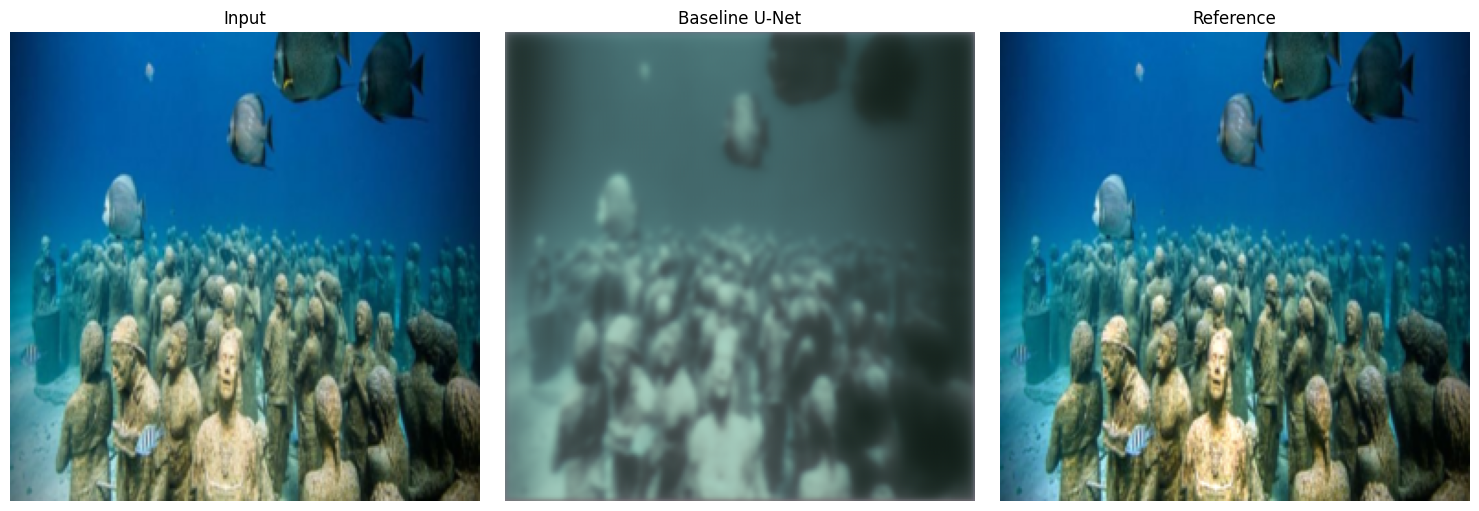

Filename: 278_img_.png


In [41]:
import matplotlib.pyplot as plt

model.eval()

batch = next(iter(test_loader))

inputs = batch["input"].to(device)
targets = batch["target"].to(device)

with torch.no_grad():
    outputs = model(inputs)

input_img = inputs[0].cpu().permute(1, 2, 0).numpy()
output_img = outputs[0].cpu().permute(1, 2, 0).numpy()
target_img = targets[0].cpu().permute(1, 2, 0).numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_img)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(output_img)
plt.title("Baseline U-Net")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(target_img)
plt.title("Reference")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Filename:", batch["filename"][0])

step-20-baseline setups

In [42]:
import json

baseline_results = {
    "model": "Baseline U-Net",
    "train_images": 800,
    "test_images": 90,
    "image_size": 256,
    "batch_size": BATCH_SIZE,
    "epochs": NUM_EPOCHS,
    "learning_rate": 1e-4,
    "loss": "L1",
    "test_l1": avg_test_loss,
    "test_psnr": test_psnr,
    "test_ssim": test_ssim
}

with open(
    "/kaggle/working/baseline_results.json",
    "w"
) as f:
    json.dump(baseline_results, f, indent=4)

print("✅ Baseline results saved.")

✅ Baseline results saved.


# E2 = Dual-Branch Network + L1 loss

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ==========================================
# Basic convolution block
# ==========================================
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ==========================================
# Illumination Branch
# ==========================================
class IlluminationBranch(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = ConvBlock(3, 32)
        self.conv2 = ConvBlock(32, 64)
        self.conv3 = ConvBlock(64, 64)

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        return x


# ==========================================
# Color / Haze Branch
# ==========================================
class ColorHazeBranch(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = ConvBlock(3, 32)
        self.conv2 = ConvBlock(32, 64)
        self.conv3 = ConvBlock(64, 64)

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        return x


# ==========================================
# Dual-Branch Network
# ==========================================
class DualBranchNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Two separate branches
        self.illumination_branch = IlluminationBranch()
        self.color_haze_branch = ColorHazeBranch()

        # Fusion
        self.fusion = nn.Sequential(
            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )

        # Reconstruction
        self.decoder = nn.Sequential(
            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                16,
                3,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        # Branch 1: illumination
        illumination_features = self.illumination_branch(x)

        # Branch 2: color/haze
        color_haze_features = self.color_haze_branch(x)

        # Concatenate features
        fused = torch.cat(
            [
                illumination_features,
                color_haze_features
            ],
            dim=1
        )

        # Fusion
        fused = self.fusion(fused)

        # Reconstruction
        output = self.decoder(fused)

        # Keep output in [0,1]
        output = torch.sigmoid(output)

        return output

In [44]:
dual_model = DualBranchNet().to(device)

print(dual_model)

DualBranchNet(
  (illumination_branch): IlluminationBranch(
    (conv1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (conv2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (conv3): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
  )
  (color_haze_branch): ColorHazeBranch(
    (conv1): ConvBlock(
      (block

In [45]:
total_params = sum(
    p.numel()
    for p in dual_model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {total_params:,}")
print(f"Trainable parameters: {total_params / 1e6:.2f} M")

Trainable parameters: 413,091
Trainable parameters: 0.41 M


In [46]:
batch = next(iter(train_loader))

inputs = batch["input"].to(device)

with torch.no_grad():
    outputs = dual_model(inputs)

print("Input shape :", inputs.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([8, 3, 256, 256])
Output shape: torch.Size([8, 3, 256, 256])


In [47]:
print("Minimum output value:", outputs.min().item())
print("Maximum output value:", outputs.max().item())

Minimum output value: 0.48949334025382996
Maximum output value: 0.5133936405181885


In [48]:
dual_criterion = nn.L1Loss()

dual_optimizer = torch.optim.AdamW(
    dual_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

dual_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    dual_optimizer,
    T_max=20
)

print("E2 training setup ready!")

E2 training setup ready!


In [ ]:
import time

NUM_EPOCHS = 20

dual_train_losses = []

best_dual_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    dual_model.train()

    running_loss = 0.0

    start_time = time.time()

    for batch in train_loader:

        inputs = batch["input"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        # Clear gradients
        dual_optimizer.zero_grad(set_to_none=True)

        # Forward
        outputs = dual_model(inputs)

        # L1 loss
        loss = dual_criterion(outputs, targets)

        # Backpropagation
        loss.backward()

        # Update weights
        dual_optimizer.step()

        running_loss += loss.item()

    # Average epoch loss
    epoch_loss = running_loss / len(train_loader)

    dual_train_losses.append(epoch_loss)

    # Learning-rate update
    dual_scheduler.step()

    current_lr = dual_optimizer.param_groups[0]["lr"]

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.6f} "
        f"LR: {current_lr:.7f} "
        f"Time: {elapsed:.1f}s"
    )

    # Save best model
    if epoch_loss < best_dual_loss:

        best_dual_loss = epoch_loss

        torch.save(
            dual_model.state_dict(),
            "/kaggle/working/dual_branch_best.pth"
        )

print("\nE2 training complete.")
print("Best training loss:", best_dual_loss)

In [ ]:
dual_model.load_state_dict(
    torch.load(
        "/kaggle/working/dual_branch_best.pth",
        map_location=device
    )
)

dual_model.eval()

print("Best E2 model loaded.")

In [49]:
from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure

dual_psnr_metric = PeakSignalNoiseRatio(
    data_range=1.0
).to(device)

dual_ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)

dual_test_l1 = 0.0

with torch.no_grad():

    for batch in test_loader:

        inputs = batch["input"].to(device)
        targets = batch["target"].to(device)

        outputs = dual_model(inputs)

        dual_test_l1 += dual_criterion(
            outputs,
            targets
        ).item()

        dual_psnr_metric.update(
            outputs,
            targets
        )

        dual_ssim_metric.update(
            outputs,
            targets
        )

dual_test_l1 /= len(test_loader)

dual_psnr = dual_psnr_metric.compute().item()
dual_ssim = dual_ssim_metric.compute().item()

print("\nE2 Dual-Branch Test Results")
print("---------------------------")
print(f"L1 Loss : {dual_test_l1:.6f}")
print(f"PSNR    : {dual_psnr:.4f} dB")
print(f"SSIM    : {dual_ssim:.4f}")


E2 Dual-Branch Test Results
---------------------------
L1 Loss : 0.221378
PSNR    : 11.7367 dB
SSIM    : 0.3166


# E3 + E4 — Combined implementation

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# =========================================================
# Channel Attention
# =========================================================

class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=8):
        super().__init__()

        hidden = max(channels // reduction, 4)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):

        attention = self.fc(
            self.avg_pool(x)
        )

        return x * attention


# =========================================================
# Spatial Attention
# =========================================================

class SpatialAttention(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=7,
            padding=3,
            bias=False
        )

    def forward(self, x):

        avg_map = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        max_map = torch.max(
            x,
            dim=1,
            keepdim=True
        )[0]

        combined = torch.cat(
            [avg_map, max_map],
            dim=1
        )

        attention = torch.sigmoid(
            self.conv(combined)
        )

        return x * attention


# =========================================================
# Adaptive Gated Fusion
# =========================================================

class AdaptiveGatedFusion(nn.Module):

    def __init__(self, channels=64):

        super().__init__()

        # Learn how much information to take
        # from each branch.
        self.gate = nn.Sequential(

            nn.Conv2d(
                channels * 2,
                channels,
                kernel_size=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

        self.fusion = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, illumination, color_haze):

        combined = torch.cat(
            [illumination, color_haze],
            dim=1
        )

        gate = self.gate(combined)

        # Adaptive weighted fusion
        fused = (
            gate * illumination
            +
            (1 - gate) * color_haze
        )

        fused = F.relu(
            self.fusion(fused),
            inplace=True
        )

        return fused


# =========================================================
# E3 Model
# Dual Branch + Adaptive Gated Fusion
# =========================================================

class E3_GatedDualBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.illumination_branch = IlluminationBranch()
        self.color_haze_branch = ColorHazeBranch()

        self.gated_fusion = AdaptiveGatedFusion(
            channels=64
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                16,
                3,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        illumination = self.illumination_branch(x)

        color_haze = self.color_haze_branch(x)

        fused = self.gated_fusion(
            illumination,
            color_haze
        )

        output = self.decoder(fused)

        return torch.sigmoid(output)


# =========================================================
# E4 Model
# E3 + Channel & Spatial Attention
# =========================================================

class E4_AttentionDualBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.illumination_branch = IlluminationBranch()
        self.color_haze_branch = ColorHazeBranch()

        self.gated_fusion = AdaptiveGatedFusion(
            channels=64
        )

        # Attention
        self.channel_attention = ChannelAttention(
            channels=64
        )

        self.spatial_attention = SpatialAttention()

        self.decoder = nn.Sequential(

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                16,
                3,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        illumination = self.illumination_branch(x)

        color_haze = self.color_haze_branch(x)

        fused = self.gated_fusion(
            illumination,
            color_haze
        )

        # Channel attention
        fused = self.channel_attention(fused)

        # Spatial attention
        fused = self.spatial_attention(fused)

        output = self.decoder(fused)

        return torch.sigmoid(output)

In [51]:
e3_model = E3_GatedDualBranch().to(device)

batch = next(iter(train_loader))

inputs = batch["input"].to(device)

with torch.no_grad():
    e3_output = e3_model(inputs)

print("E3 input :", inputs.shape)
print("E3 output:", e3_output.shape)

E3 input : torch.Size([8, 3, 256, 256])
E3 output: torch.Size([8, 3, 256, 256])


In [52]:
e4_model = E4_AttentionDualBranch().to(device)

with torch.no_grad():
    e4_output = e4_model(inputs)

print("E4 input :", inputs.shape)
print("E4 output:", e4_output.shape)

E4 input : torch.Size([8, 3, 256, 256])
E4 output: torch.Size([8, 3, 256, 256])


In [53]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print(
    f"E3 parameters: "
    f"{count_parameters(e3_model):,}"
)

print(
    f"E4 parameters: "
    f"{count_parameters(e4_model):,}"
)

E3 parameters: 351,715
E4 parameters: 352,837


**evaluate E3**

In [56]:
import time

e3_criterion = nn.L1Loss()

e3_optimizer = torch.optim.AdamW(
    e3_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

e3_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    e3_optimizer,
    T_max=20
)

e3_losses = []

best_e3_loss = float("inf")

NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):

    e3_model.train()

    running_loss = 0.0

    start_time = time.time()

    for batch in train_loader:

        inputs = batch["input"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        e3_optimizer.zero_grad(
            set_to_none=True
        )

        outputs = e3_model(inputs)

        loss = e3_criterion(
            outputs,
            targets
        )

        loss.backward()

        e3_optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    e3_losses.append(epoch_loss)

    e3_scheduler.step()

    lr = e3_optimizer.param_groups[0]["lr"]

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.6f} "
        f"LR: {lr:.7f} "
        f"Time: {elapsed:.1f}s"
    )

    if epoch_loss < best_e3_loss:

        best_e3_loss = epoch_loss

        torch.save(
            e3_model.state_dict(),
            "/kaggle/working/e3_best.pth"
        )

print("\nE3 training complete.")
print("Best E3 loss:", best_e3_loss)

Epoch [01/20] Loss: 0.192696 LR: 0.0000994 Time: 38.2s
Epoch [02/20] Loss: 0.149418 LR: 0.0000976 Time: 37.6s
Epoch [03/20] Loss: 0.131194 LR: 0.0000946 Time: 38.1s
Epoch [04/20] Loss: 0.124492 LR: 0.0000905 Time: 37.8s
Epoch [05/20] Loss: 0.122874 LR: 0.0000854 Time: 38.4s
Epoch [06/20] Loss: 0.119179 LR: 0.0000794 Time: 37.9s
Epoch [07/20] Loss: 0.116391 LR: 0.0000727 Time: 38.0s
Epoch [08/20] Loss: 0.114262 LR: 0.0000655 Time: 38.1s
Epoch [09/20] Loss: 0.113936 LR: 0.0000578 Time: 38.2s
Epoch [10/20] Loss: 0.114966 LR: 0.0000500 Time: 38.2s
Epoch [11/20] Loss: 0.113461 LR: 0.0000422 Time: 38.4s
Epoch [12/20] Loss: 0.111352 LR: 0.0000345 Time: 38.2s
Epoch [13/20] Loss: 0.112159 LR: 0.0000273 Time: 38.2s
Epoch [14/20] Loss: 0.109690 LR: 0.0000206 Time: 38.2s
Epoch [15/20] Loss: 0.109868 LR: 0.0000146 Time: 38.2s
Epoch [16/20] Loss: 0.109186 LR: 0.0000095 Time: 38.5s
Epoch [17/20] Loss: 0.109797 LR: 0.0000054 Time: 38.4s
Epoch [18/20] Loss: 0.109040 LR: 0.0000024 Time: 38.2s
Epoch [19/

In [57]:
e3_model.load_state_dict(
    torch.load(
        "/kaggle/working/e3_best.pth",
        map_location=device
    )
)

e3_model.eval()

e3_psnr_metric = PeakSignalNoiseRatio(
    data_range=1.0
).to(device)

e3_ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)

e3_test_l1 = 0.0

with torch.no_grad():

    for batch in test_loader:

        inputs = batch["input"].to(device)
        targets = batch["target"].to(device)

        outputs = e3_model(inputs)

        e3_test_l1 += e3_criterion(
            outputs,
            targets
        ).item()

        e3_psnr_metric.update(
            outputs,
            targets
        )

        e3_ssim_metric.update(
            outputs,
            targets
        )

e3_test_l1 /= len(test_loader)

e3_psnr = e3_psnr_metric.compute().item()
e3_ssim = e3_ssim_metric.compute().item()

print("\nE3 Results")
print("---------------------------")
print(f"L1 Loss : {e3_test_l1:.6f}")
print(f"PSNR    : {e3_psnr:.4f} dB")
print(f"SSIM    : {e3_ssim:.4f}")


E3 Results
---------------------------
L1 Loss : 0.114648
PSNR    : 16.4423 dB
SSIM    : 0.6224


**Train E4**

In [54]:
e4_criterion = nn.L1Loss()

e4_optimizer = torch.optim.AdamW(
    e4_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

e4_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    e4_optimizer,
    T_max=20
)

e4_losses = []

best_e4_loss = float("inf")

for epoch in range(20):

    e4_model.train()

    running_loss = 0.0

    start_time = time.time()

    for batch in train_loader:

        inputs = batch["input"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        e4_optimizer.zero_grad(
            set_to_none=True
        )

        outputs = e4_model(inputs)

        loss = e4_criterion(
            outputs,
            targets
        )

        loss.backward()

        e4_optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    e4_losses.append(epoch_loss)

    e4_scheduler.step()

    lr = e4_optimizer.param_groups[0]["lr"]

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/20] "
        f"Loss: {epoch_loss:.6f} "
        f"LR: {lr:.7f} "
        f"Time: {elapsed:.1f}s"
    )

    if epoch_loss < best_e4_loss:

        best_e4_loss = epoch_loss

        torch.save(
            e4_model.state_dict(),
            "/kaggle/working/e4_best.pth"
        )

print("\nE4 training complete.")
print("Best E4 loss:", best_e4_loss)

Epoch [01/20] Loss: 0.201119 LR: 0.0000994 Time: 41.0s
Epoch [02/20] Loss: 0.160222 LR: 0.0000976 Time: 39.2s
Epoch [03/20] Loss: 0.136354 LR: 0.0000946 Time: 40.2s
Epoch [04/20] Loss: 0.125442 LR: 0.0000905 Time: 39.7s
Epoch [05/20] Loss: 0.124027 LR: 0.0000854 Time: 39.8s
Epoch [06/20] Loss: 0.119122 LR: 0.0000794 Time: 39.7s
Epoch [07/20] Loss: 0.119521 LR: 0.0000727 Time: 40.0s
Epoch [08/20] Loss: 0.117282 LR: 0.0000655 Time: 39.9s
Epoch [09/20] Loss: 0.113543 LR: 0.0000578 Time: 39.8s
Epoch [10/20] Loss: 0.111794 LR: 0.0000500 Time: 40.1s
Epoch [11/20] Loss: 0.110760 LR: 0.0000422 Time: 40.0s
Epoch [12/20] Loss: 0.107450 LR: 0.0000345 Time: 40.1s
Epoch [13/20] Loss: 0.107067 LR: 0.0000273 Time: 40.1s
Epoch [14/20] Loss: 0.107155 LR: 0.0000206 Time: 40.1s
Epoch [15/20] Loss: 0.105272 LR: 0.0000146 Time: 40.1s
Epoch [16/20] Loss: 0.104609 LR: 0.0000095 Time: 40.1s
Epoch [17/20] Loss: 0.103082 LR: 0.0000054 Time: 40.1s
Epoch [18/20] Loss: 0.104256 LR: 0.0000024 Time: 40.5s
Epoch [19/

In [55]:
e4_model.load_state_dict(
    torch.load(
        "/kaggle/working/e4_best.pth",
        map_location=device
    )
)

e4_model.eval()

e4_psnr_metric = PeakSignalNoiseRatio(
    data_range=1.0
).to(device)

e4_ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)

e4_test_l1 = 0.0

with torch.no_grad():

    for batch in test_loader:

        inputs = batch["input"].to(device)
        targets = batch["target"].to(device)

        outputs = e4_model(inputs)

        e4_test_l1 += e4_criterion(
            outputs,
            targets
        ).item()

        e4_psnr_metric.update(
            outputs,
            targets
        )

        e4_ssim_metric.update(
            outputs,
            targets
        )

e4_test_l1 /= len(test_loader)

e4_psnr = e4_psnr_metric.compute().item()
e4_ssim = e4_ssim_metric.compute().item()

print("\nE4 Results")
print("---------------------------")
print(f"L1 Loss : {e4_test_l1:.6f}")
print(f"PSNR    : {e4_psnr:.4f} dB")
print(f"SSIM    : {e4_ssim:.4f}")


E4 Results
---------------------------
L1 Loss : 0.107472
PSNR    : 16.9697 dB
SSIM    : 0.6351


# SSIM loss

In [58]:
import torch
import torch.nn.functional as F


def ssim_loss(pred, target):
    """
    Differentiable SSIM-based loss.
    Lower is better.
    """

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu_x = F.avg_pool2d(
        pred,
        kernel_size=11,
        stride=1,
        padding=5
    )

    mu_y = F.avg_pool2d(
        target,
        kernel_size=11,
        stride=1,
        padding=5
    )

    sigma_x = F.avg_pool2d(
        pred * pred,
        kernel_size=11,
        stride=1,
        padding=5
    ) - mu_x * mu_x

    sigma_y = F.avg_pool2d(
        target * target,
        kernel_size=11,
        stride=1,
        padding=5
    ) - mu_y * mu_y

    sigma_xy = F.avg_pool2d(
        pred * target,
        kernel_size=11,
        stride=1,
        padding=5
    ) - mu_x * mu_y

    ssim_map = (
        (2 * mu_x * mu_y + C1)
        *
        (2 * sigma_xy + C2)
    ) / (
        (mu_x * mu_x + mu_y * mu_y + C1)
        *
        (sigma_x + sigma_y + C2)
    )

    return 1.0 - ssim_map.mean()

# Final Model

In [59]:
class FinalDualBranchNet(nn.Module):

    def __init__(self):
        super().__init__()

        # -----------------------------------------
        # Illumination branch
        # -----------------------------------------
        self.illumination_branch = IlluminationBranch()

        # -----------------------------------------
        # Color / haze branch
        # -----------------------------------------
        self.color_haze_branch = ColorHazeBranch()

        # -----------------------------------------
        # Adaptive gated fusion
        # -----------------------------------------
        self.gated_fusion = AdaptiveGatedFusion(
            channels=64
        )

        # -----------------------------------------
        # Channel attention
        # -----------------------------------------
        self.channel_attention = ChannelAttention(
            channels=64
        )

        # -----------------------------------------
        # Spatial attention
        # -----------------------------------------
        self.spatial_attention = SpatialAttention()

        # -----------------------------------------
        # Reconstruction
        # -----------------------------------------
        self.decoder = nn.Sequential(

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                16,
                3,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        # Two specialized branches
        illumination = self.illumination_branch(x)

        color_haze = self.color_haze_branch(x)

        # Adaptive fusion
        fused = self.gated_fusion(
            illumination,
            color_haze
        )

        # Channel attention
        fused = self.channel_attention(fused)

        # Spatial attention
        fused = self.spatial_attention(fused)

        # Reconstruction
        residual = self.decoder(fused)

        # Residual enhancement
        output = x + residual

        # Valid image range
        output = torch.clamp(
            output,
            0.0,
            1.0
        )

        return output

In [60]:
final_model = FinalDualBranchNet().to(device)

params = count_parameters(final_model)

print(
    f"Final model parameters: {params:,}"
)

print(
    f"Final model parameters: {params / 1e6:.2f} M"
)

Final model parameters: 389,765
Final model parameters: 0.39 M


In [61]:
batch = next(iter(train_loader))

inputs = batch["input"].to(device)

with torch.no_grad():
    final_output = final_model(inputs)

print("Input :", inputs.shape)
print("Output:", final_output.shape)

print(
    "Output range:",
    final_output.min().item(),
    "to",
    final_output.max().item()
)

Input : torch.Size([8, 3, 256, 256])
Output: torch.Size([8, 3, 256, 256])
Output range: 0.0 to 1.0


In [62]:
final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    final_optimizer,
    T_max=20
)

L1_WEIGHT = 0.8
SSIM_WEIGHT = 0.2

final_losses = []

best_final_loss = float("inf")

NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):

    final_model.train()

    running_loss = 0.0

    start_time = time.time()

    for batch in train_loader:

        inputs = batch["input"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        final_optimizer.zero_grad(
            set_to_none=True
        )

        outputs = final_model(inputs)

        # L1
        l1 = F.l1_loss(
            outputs,
            targets
        )

        # SSIM
        ssim = ssim_loss(
            outputs,
            targets
        )

        # Hybrid differentiable loss
        loss = (
            L1_WEIGHT * l1
            +
            SSIM_WEIGHT * ssim
        )

        loss.backward()

        final_optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    final_losses.append(epoch_loss)

    final_scheduler.step()

    lr = final_optimizer.param_groups[0]["lr"]

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.6f} "
        f"LR: {lr:.7f} "
        f"Time: {elapsed:.1f}s"
    )

    if epoch_loss < best_final_loss:

        best_final_loss = epoch_loss

        torch.save(
            final_model.state_dict(),
            "/kaggle/working/final_model_best.pth"
        )

print("\nFinal model training complete.")
print("Best loss:", best_final_loss)

Epoch [01/20] Loss: 0.134645 LR: 0.0000994 Time: 46.3s
Epoch [02/20] Loss: 0.126041 LR: 0.0000976 Time: 43.7s
Epoch [03/20] Loss: 0.121100 LR: 0.0000946 Time: 43.9s
Epoch [04/20] Loss: 0.121169 LR: 0.0000905 Time: 43.9s
Epoch [05/20] Loss: 0.121372 LR: 0.0000854 Time: 44.1s
Epoch [06/20] Loss: 0.119403 LR: 0.0000794 Time: 44.1s
Epoch [07/20] Loss: 0.116509 LR: 0.0000727 Time: 44.3s
Epoch [08/20] Loss: 0.114741 LR: 0.0000655 Time: 44.3s
Epoch [09/20] Loss: 0.112885 LR: 0.0000578 Time: 44.3s
Epoch [10/20] Loss: 0.112136 LR: 0.0000500 Time: 44.3s
Epoch [11/20] Loss: 0.109786 LR: 0.0000422 Time: 44.4s
Epoch [12/20] Loss: 0.109712 LR: 0.0000345 Time: 44.4s
Epoch [13/20] Loss: 0.109913 LR: 0.0000273 Time: 44.5s
Epoch [14/20] Loss: 0.109613 LR: 0.0000206 Time: 44.4s
Epoch [15/20] Loss: 0.107273 LR: 0.0000146 Time: 44.6s
Epoch [16/20] Loss: 0.107776 LR: 0.0000095 Time: 44.6s
Epoch [17/20] Loss: 0.107812 LR: 0.0000054 Time: 44.5s
Epoch [18/20] Loss: 0.106247 LR: 0.0000024 Time: 44.6s
Epoch [19/

In [63]:
final_model.load_state_dict(
    torch.load(
        "/kaggle/working/final_model_best.pth",
        map_location=device
    )
)

final_model.eval()

print("Best final model loaded successfully.")

Best final model loaded successfully.


In [64]:
from torchmetrics.image import (
    PeakSignalNoiseRatio,
    StructuralSimilarityIndexMeasure
)

final_psnr_metric = PeakSignalNoiseRatio(
    data_range=1.0
).to(device)

final_ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)

final_test_l1 = 0.0

with torch.no_grad():

    for batch in test_loader:

        inputs = batch["input"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        outputs = final_model(inputs)

        # L1
        final_test_l1 += F.l1_loss(
            outputs,
            targets
        ).item()

        # PSNR
        final_psnr_metric.update(
            outputs,
            targets
        )

        # SSIM
        final_ssim_metric.update(
            outputs,
            targets
        )

final_test_l1 /= len(test_loader)

final_psnr = final_psnr_metric.compute().item()
final_ssim = final_ssim_metric.compute().item()

print("\nFINAL MODEL — PAIRED TEST RESULTS")
print("===================================")
print(f"L1 Loss : {final_test_l1:.6f}")
print(f"PSNR    : {final_psnr:.4f} dB")
print(f"SSIM    : {final_ssim:.4f}")


FINAL MODEL — PAIRED TEST RESULTS
L1 Loss : 0.101700
PSNR    : 17.2100 dB
SSIM    : 0.8370


In [65]:
results_table = {
    "E1 U-Net + L1": {
        "L1": 0.098404,
        "PSNR": 17.6975,
        "SSIM": 0.7422
    },

    "E2 Dual Branch + L1": {
        "L1": 0.109799,
        "PSNR": 16.6839,
        "SSIM": 0.6913
    },

    "E3 + Gated Fusion": {
        "L1": 0.114648,
        "PSNR": 16.4423,
        "SSIM": 0.6224
    },

    "E4 + Attention": {
        "L1": 0.107472,
        "PSNR": 16.9697,
        "SSIM": 0.6351
    },

    "E5 Final Model": {
        "L1": final_test_l1,
        "PSNR": final_psnr,
        "SSIM": final_ssim
    }
}

print("\nFINAL ABLATION RESULTS")
print("=" * 70)

print(
    f"{'Experiment':<28}"
    f"{'L1':>12}"
    f"{'PSNR':>12}"
    f"{'SSIM':>12}"
)

print("-" * 70)

for name, result in results_table.items():

    print(
        f"{name:<28}"
        f"{result['L1']:>12.6f}"
        f"{result['PSNR']:>12.4f}"
        f"{result['SSIM']:>12.4f}"
    )


FINAL ABLATION RESULTS
Experiment                            L1        PSNR        SSIM
----------------------------------------------------------------------
E1 U-Net + L1                   0.098404     17.6975      0.7422
E2 Dual Branch + L1             0.109799     16.6839      0.6913
E3 + Gated Fusion               0.114648     16.4423      0.6224
E4 + Attention                  0.107472     16.9697      0.6351
E5 Final Model                  0.101700     17.2100      0.8370


In [66]:
final_params = sum(
    p.numel()
    for p in final_model.parameters()
    if p.requires_grad
)

print("Final model parameters:")
print(f"{final_params:,}")
print(f"{final_params / 1e6:.3f} M")

Final model parameters:
389,765
0.390 M


In [67]:
baseline_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nBaseline U-Net parameters:")
print(f"{baseline_params:,}")
print(f"{baseline_params / 1e6:.3f} M")


Baseline U-Net parameters:
31,031,875
31.032 M


In [68]:
import time

final_model.eval()

batch = next(iter(test_loader))

sample_input = batch["input"].to(
    device,
    non_blocking=True
)

# Warm-up
with torch.no_grad():

    for _ in range(10):
        _ = final_model(sample_input)

if device.type == "cuda":
    torch.cuda.synchronize()

# Timing
start_time = time.time()

with torch.no_grad():
    for _ in range(30):
        _ = final_model(sample_input)

if device.type == "cuda":
    torch.cuda.synchronize()

end_time = time.time()

total_time = end_time - start_time

average_batch_time = total_time / 30

batch_size = sample_input.shape[0]

average_image_time = (
    average_batch_time / batch_size
)

fps = 1 / average_image_time

print("FINAL MODEL INFERENCE")
print("=====================")
print(f"Batch size        : {batch_size}")
print(f"Average batch time: {average_batch_time * 1000:.2f} ms")
print(f"Average image time: {average_image_time * 1000:.2f} ms")
print(f"Throughput        : {fps:.2f} images/sec")

FINAL MODEL INFERENCE
Batch size        : 8
Average batch time: 133.38 ms
Average image time: 16.67 ms
Throughput        : 59.98 images/sec


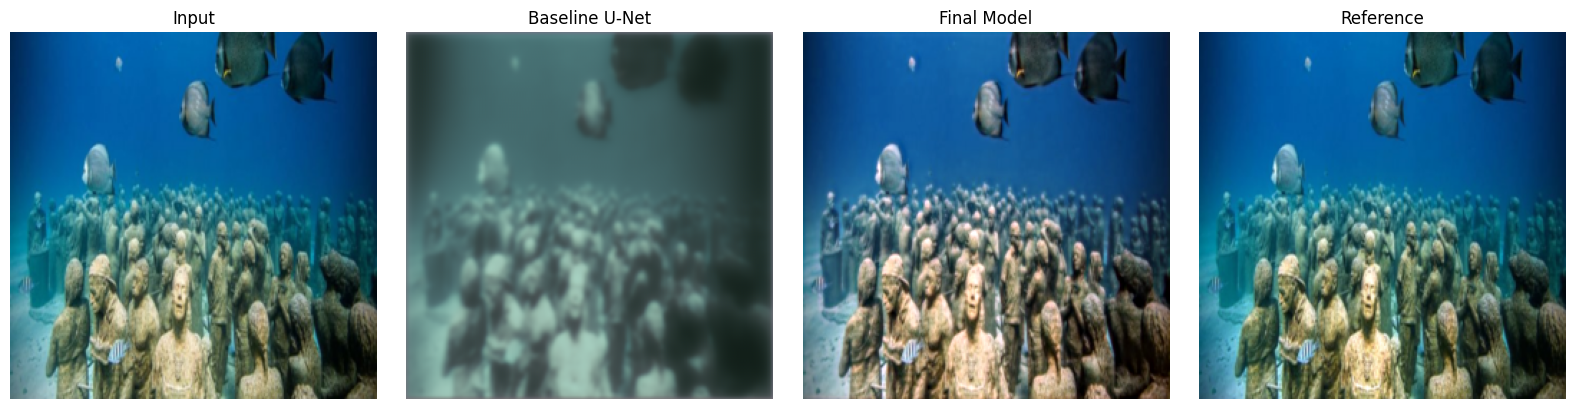

In [69]:
import matplotlib.pyplot as plt

# Get one test batch
batch = next(iter(test_loader))

inputs = batch["input"].to(device)
targets = batch["target"].to(device)

# Baseline prediction
model.eval()

with torch.no_grad():
    baseline_output = model(inputs)

# Final prediction
final_model.eval()

with torch.no_grad():
    final_output = final_model(inputs)

# Move first image to CPU
input_img = inputs[0].detach().cpu().permute(1, 2, 0).numpy()
baseline_img = baseline_output[0].detach().cpu().permute(1, 2, 0).numpy()
final_img = final_output[0].detach().cpu().permute(1, 2, 0).numpy()
target_img = targets[0].detach().cpu().permute(1, 2, 0).numpy()

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(input_img)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(baseline_img)
plt.title("Baseline U-Net")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(final_img)
plt.title("Final Model")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(target_img)
plt.title("Reference")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/final_visual_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [71]:
import json

final_results = {
    "baseline": {
        "l1": 0.098404,
        "psnr": 17.6975,
        "ssim": 0.7422,
        "parameters": baseline_params
    },

    "e2_dual_branch": {
        "l1": 0.109799,
        "psnr": 16.6839,
        "ssim": 0.6913
    },

    "e3_gated_fusion": {
        "l1": 0.114648,
        "psnr": 16.4423,
        "ssim": 0.6224
    },

    "e4_attention": {
        "l1": 0.107472,
        "psnr": 16.9697,
        "ssim": 0.6351
    },

    "final_model": {
        "l1": final_test_l1,
        "psnr": final_psnr,
        "ssim": final_ssim,
        "parameters": final_params,
        "parameters_million": final_params / 1e6,
        "average_image_time_ms": average_image_time * 1000,
        "throughput_images_per_second": fps
    }
}

with open(
    "/kaggle/working/final_experiment_results.json",
    "w"
) as f:

    json.dump(
        final_results,
        f,
        indent=4
    )

print(
    "Saved: "
    "/kaggle/working/final_experiment_results.json"
)

Saved: /kaggle/working/final_experiment_results.json


# Final steps: Challenging the 60 images

In [73]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision.transforms import functional as TF
from pathlib import Path


class Challenging60Dataset(Dataset):

    def __init__(
        self,
        image_dir,
        image_size=256
    ):
        self.image_dir = Path(image_dir)
        self.image_size = image_size

        self.files = sorted([
            p for p in self.image_dir.iterdir()
            if p.suffix.lower() in {
                ".png",
                ".jpg",
                ".jpeg",
                ".bmp"
            }
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        path = self.files[idx]

        image = Image.open(path).convert("RGB")

        # Same deterministic preprocessing used
        # for our paired test images
        image = TF.resize(
            image,
            [self.image_size, self.image_size]
        )

        image_tensor = TF.to_tensor(image)

        return {
            "input": image_tensor,
            "filename": path.name
        }


challenging_dir = Path(
    "/kaggle/input/datasets/mdabdullah909/"
    "challenging-60/challenging-60"
)

challenging_dataset = Challenging60Dataset(
    challenging_dir
)

challenging_loader = DataLoader(
    challenging_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Challenging-60 images:", len(challenging_dataset))

Challenging-60 images: 60


In [74]:
batch = next(iter(challenging_loader))

inputs = batch["input"].to(device)

print("Input shape:", inputs.shape)
print("Filenames:", batch["filename"][:3])

Input shape: torch.Size([8, 3, 256, 256])
Filenames: ['100001.png', '10091.png', '10103.png']


In [75]:
import os
from PIL import Image
import numpy as np

output_dir = Path(
    "/kaggle/working/challenging60_enhanced"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

final_model.eval()

with torch.no_grad():

    for batch in challenging_loader:

        inputs = batch["input"].to(
            device,
            non_blocking=True
        )

        outputs = final_model(inputs)

        outputs = outputs.clamp(0, 1)

        for i, filename in enumerate(
            batch["filename"]
        ):

            output = outputs[i]

            output = (
                output
                .cpu()
                .permute(1, 2, 0)
                .numpy()
            )

            output = (
                output * 255
            ).round().astype(np.uint8)

            image = Image.fromarray(
                output
            )

            image.save(
                output_dir / filename
            )

print(
    "Enhanced images saved to:",
    output_dir
)

print(
    "Number of enhanced images:",
    len(list(output_dir.iterdir()))
)

Enhanced images saved to: /kaggle/working/challenging60_enhanced
Number of enhanced images: 60


In [76]:
import numpy as np
import cv2
import math
from PIL import Image

In [78]:
def calculate_uciqe(image):

    """
    Calculate UCIQE for an RGB image.
    Input:
        image: uint8 RGB image [0,255]

    Higher UCIQE generally indicates
    better non-reference underwater image quality.
    """

    image = image.astype(np.float32) / 255.0

    # RGB -> LAB
    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    L = lab[:, :, 0] / 100.0
    a = lab[:, :, 1] / 127.0
    b = lab[:, :, 2] / 127.0

    # Chroma
    chroma = np.sqrt(
        a * a + b * b
    )

    # Mean chroma
    chroma_mean = np.mean(chroma)

    # Chroma standard deviation
    chroma_std = np.std(chroma)

    # Saturation
    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2HSV
    )

    saturation = hsv[:, :, 1]

    saturation_mean = np.mean(
        saturation
    )

    # Luminance contrast
    luminance_contrast = (
        np.percentile(L, 95)
        -
        np.percentile(L, 5)
    )

    # Standard UCIQE coefficients
    c1 = 0.4680
    c2 = 0.2745
    c3 = 0.2576

    uciqe = (
        c1 * chroma_std
        +
        c2 * luminance_contrast
        +
        c3 * saturation_mean
    )

    return float(uciqe)

In [79]:
def calculate_uiqm(image):

    """
    Calculate a practical UIQM score.

    Higher values generally indicate
    better underwater image quality.
    """

    image = image.astype(np.float32) / 255.0

    # -----------------------------------------
    # UICM - Colorfulness
    # -----------------------------------------

    R = image[:, :, 0]
    G = image[:, :, 1]
    B = image[:, :, 2]

    rg = R - G
    yb = 0.5 * (R + G) - B

    rg_mean = np.mean(rg)
    yb_mean = np.mean(yb)

    rg_std = np.std(rg)
    yb_std = np.std(yb)

    uicm = (
        -0.0268 * np.sqrt(
            rg_mean ** 2 +
            yb_mean ** 2
        )
        +
        0.1586 * np.sqrt(
            rg_std ** 2 +
            yb_std ** 2
        )
    )

    # -----------------------------------------
    # UISM - Sharpness
    # -----------------------------------------

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    sobel_x = cv2.Sobel(
        gray,
        cv2.CV_32F,
        1,
        0,
        ksize=3
    )

    sobel_y = cv2.Sobel(
        gray,
        cv2.CV_32F,
        0,
        1,
        ksize=3
    )

    edge_strength = np.sqrt(
        sobel_x ** 2 +
        sobel_y ** 2
    )

    uism = np.mean(
        edge_strength
    )

    # -----------------------------------------
    # UIConM - Contrast
    # -----------------------------------------

    luminance_std = np.std(gray)

    uiconm = luminance_std

    # -----------------------------------------
    # Final UIQM
    # -----------------------------------------

    uiqm = (
        0.0282 * uicm
        +
        0.2953 * uism
        +
        3.5753 * uiconm
    )

    return float(uiqm)

In [80]:
uiqm_scores = []
uciqe_scores = []

filenames = []

for path in sorted(
    output_dir.iterdir()
):

    if path.suffix.lower() not in {
        ".png",
        ".jpg",
        ".jpeg",
        ".bmp"
    }:
        continue

    image = np.array(
        Image.open(path).convert("RGB")
    )

    uiqm = calculate_uiqm(
        image
    )

    uciqe = calculate_uciqe(
        image
    )

    filenames.append(
        path.name
    )

    uiqm_scores.append(
        uiqm
    )

    uciqe_scores.append(
        uciqe
    )


mean_uiqm = np.mean(
    uiqm_scores
)

mean_uciqe = np.mean(
    uciqe_scores
)

std_uiqm = np.std(
    uiqm_scores
)

std_uciqe = np.std(
    uciqe_scores
)


print("\nCHALLENGING-60 RESULTS")
print("======================")
print(f"Images       : {len(filenames)}")
print(f"Mean UIQM    : {mean_uiqm:.6f}")
print(f"Std UIQM     : {std_uiqm:.6f}")
print(f"Mean UCIQE   : {mean_uciqe:.6f}")
print(f"Std UCIQE    : {std_uciqe:.6f}")


CHALLENGING-60 RESULTS
Images       : 60
Mean UIQM    : 0.543819
Std UIQM     : 0.227893
Mean UCIQE   : 0.256246
Std UCIQE    : 0.080020


In [82]:
import json

c60_results = {
    "dataset": "UIEB Challenging-60",
    "num_images": len(filenames),

    "UIQM": {
        "mean": float(mean_uiqm),
        "std": float(std_uiqm)
    },

    "UCIQE": {
        "mean": float(mean_uciqe),
        "std": float(std_uciqe)
    },

    "per_image": [
        {
            "filename": filename,
            "UIQM": float(uiqm),
            "UCIQE": float(uciqe)
        }

        for filename, uiqm, uciqe
        in zip(
            filenames,
            uiqm_scores,
            uciqe_scores
        )
    ]
}

with open(
    "/kaggle/working/challenging60_results.json",
    "w"
) as f:

    json.dump(
        c60_results,
        f,
        indent=4
    )

print(
    "Saved:"
    "/kaggle/working/challenging60_results.json"
)

Saved:/kaggle/working/challenging60_results.json


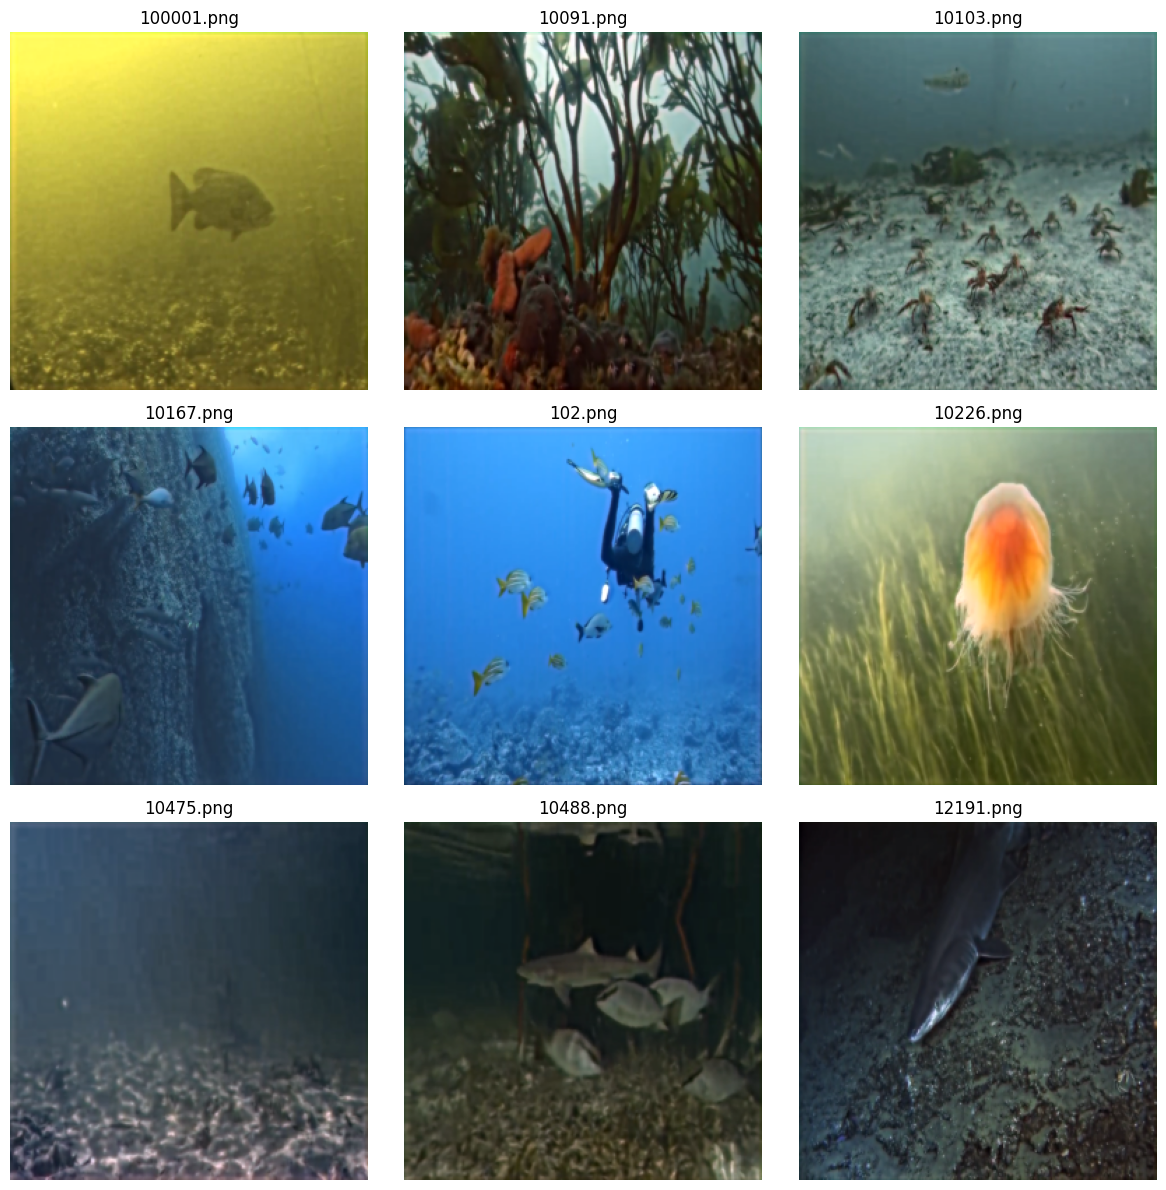

In [83]:
import matplotlib.pyplot as plt

sample_files = filenames[:9]

plt.figure(
    figsize=(12, 12)
)

for i, filename in enumerate(
    sample_files
):

    image = np.array(
        Image.open(
            output_dir / filename
        ).convert("RGB")
    )

    plt.subplot(
        3,
        3,
        i + 1
    )

    plt.imshow(image)

    plt.title(filename)

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "challenging60_visual_grid.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

RAkibul hasan

In [ ]:
# 1.1 Installs (uncomment if running in a fresh environment)
# !pip install torch torchvision scikit-image opencv-python-headless matplotlib tqdm --quiet

import os
import glob
import random
import math
import time
from dataclasses import dataclass, field

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
